# Import pandas and os

In [7]:
import pandas as pd
import os
print(os.getcwd())

c:\Users\mukta\Documents\2026\JobProjects\ml-projects-portfolio\customer-churn-project


# Load data

In [16]:
df = pd.read_csv('data/churn.csv')
# Display the first few rows of the DataFrame
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

# Display the shape of the DataFrame

In [ ]:

print(df.shape)

(7043, 21)


# Display the summary information about the DataFrame

In [18]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Data frame contains 7043 columns and 21 rows
MonthlyCharges data type float64

# Convert 'TotalCharges' to numeric, coercing errors to NaN

In [19]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

# Display the summary statistics of the DataFrame

In [20]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000
mean,0.162147,32.371149,64.761692,2283.300441,0.265370
std,0.368612,24.559481,30.090047,2266.771362,0.441561
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.500000,401.450000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.850000,3794.737500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


1. Tenure: mean = 32 months and max =72 months

# Check for duplicate rows

In [21]:
duplicate_rows = df[df.duplicated()]
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")

Number of duplicate rows: 0


There are no duplicate rows.

# Display the correlation matrix

In [22]:
df1 = df.corr(numeric_only=True)
df1


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
SeniorCitizen,1.000000,0.016567,0.220173,0.102411,0.150889
tenure,0.016567,1.000000,0.247900,0.825880,-0.352229
MonthlyCharges,0.220173,0.247900,1.000000,0.651065,0.193356
TotalCharges,0.102411,0.825880,0.651065,1.000000,-0.199484
Churn,0.150889,-0.352229,0.193356,-0.199484,1.000000


# import seaborn

In [25]:
import seaborn as sns

# Heatmap

<Axes: >

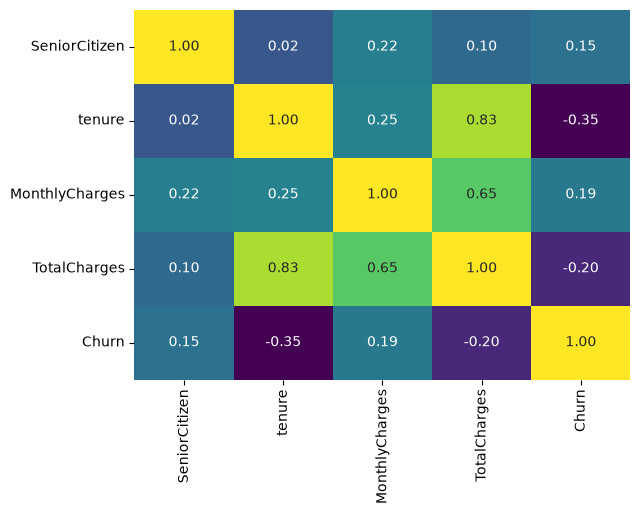

In [26]:
sns.heatmap(df1, cbar=False, cmap='viridis', annot=True, fmt='.2f')

# Checking null values

In [28]:
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

There are 11 null values in TotalCharges column

# Drop the 'customerID' column as it is not useful for analysis

In [29]:
df.drop(columns=['customerID'], inplace=True)

# Display the value counts of the 'Churn' column

In [30]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

# Bar plot

<Axes: title={'center': 'Churn Distribution'}, xlabel='Churn', ylabel='Count'>

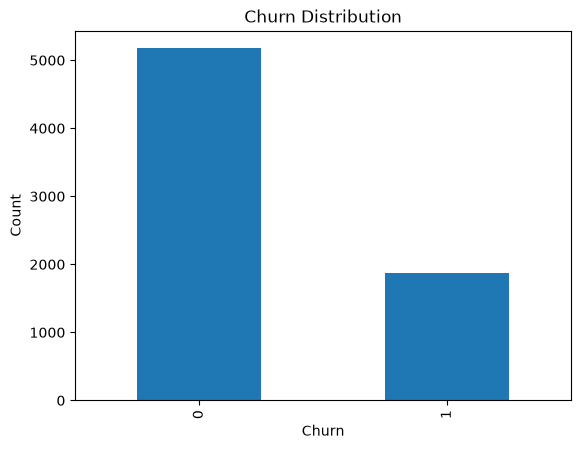

In [31]:
df['Churn'].value_counts().plot(kind='bar', title='Churn Distribution',
                                    xlabel='Churn', ylabel='Count')

The number of churned customers is significantly lower than the number of non-churned customers, indicating an imbalanced dataset. This imbalance may affect the performance of machine learning models, and techniques such as resampling or using appropriate evaluation metrics should be considered during model development.

# Display the percentage of churned vs non-churned customers

In [32]:
df['Churn'].value_counts()/len(df)

Churn
0    0.73463
1    0.26537
Name: count, dtype: float64

# Define the categorical and numerical columns, and the target column

In [33]:
categorical_cols = ['gender', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
print(categorical_cols)
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
print(numerical_cols)
target_col = 'Churn'
print(target_col)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
['tenure', 'MonthlyCharges', 'TotalCharges']
Churn


# Display the skewness of the numerical columns

In [34]:
df.skew(numeric_only=True)

SeniorCitizen     1.833633
tenure            0.239540
MonthlyCharges   -0.220524
TotalCharges      0.961642
Churn             1.063031
dtype: float64

# Plot histograms for the numerical columns

array([[<Axes: title={'center': 'tenure'}>,
        <Axes: title={'center': 'MonthlyCharges'}>],
       [<Axes: title={'center': 'TotalCharges'}>, <Axes: >]], dtype=object)

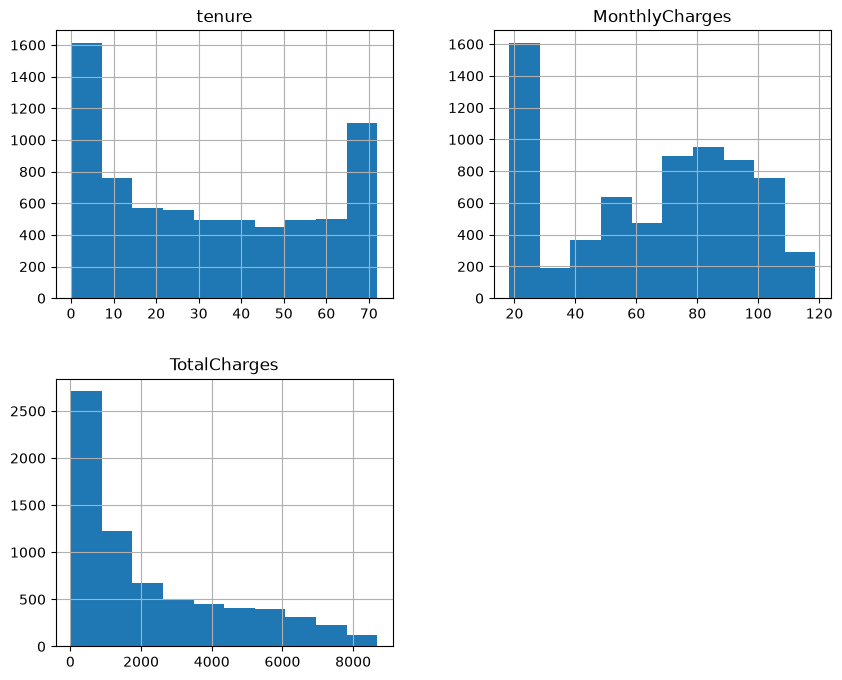

In [35]:
df[numerical_cols].hist(figsize=(10, 8))

  # Bar plot for categorical columns

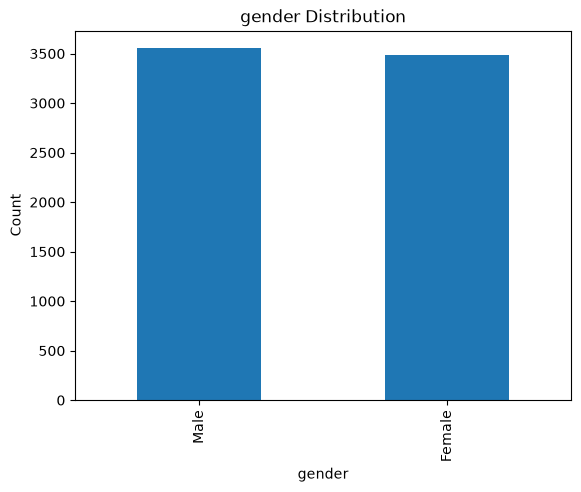

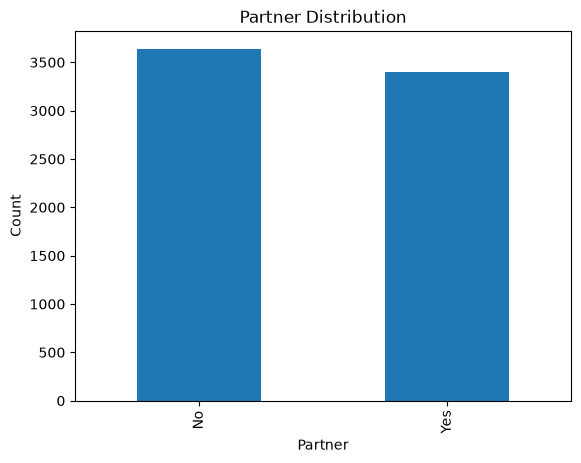

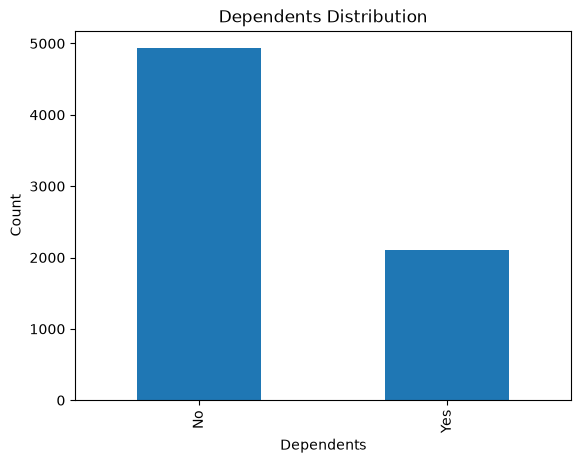

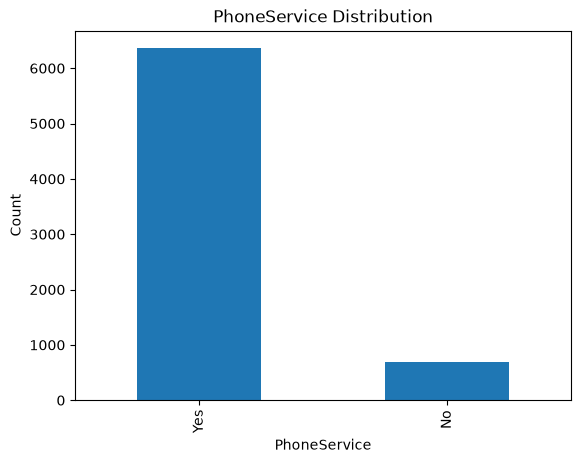

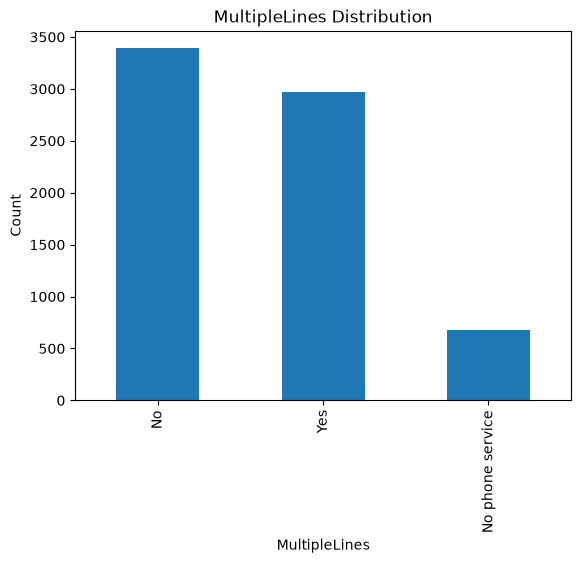

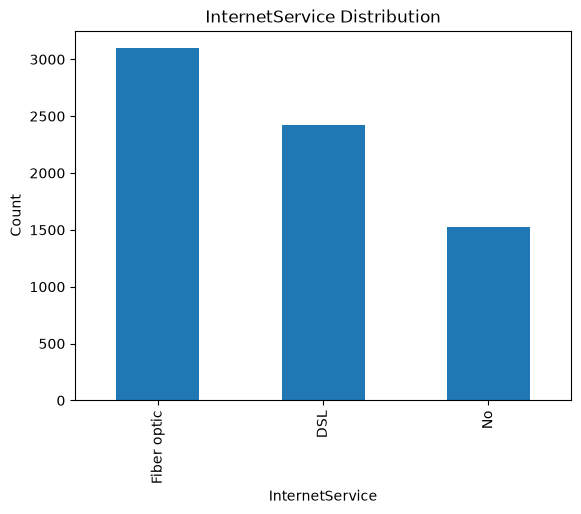

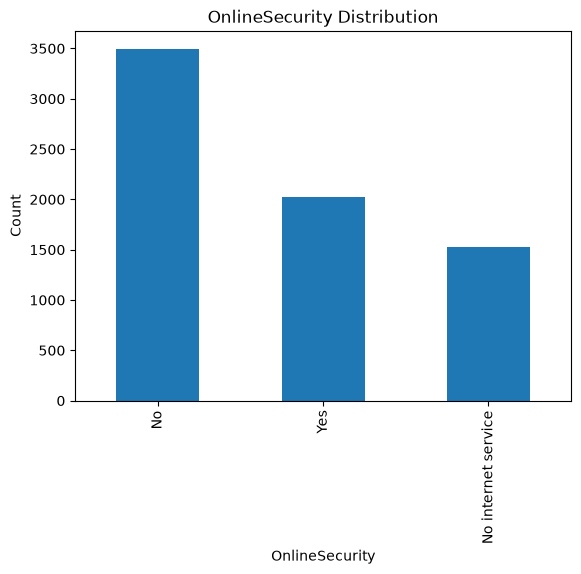

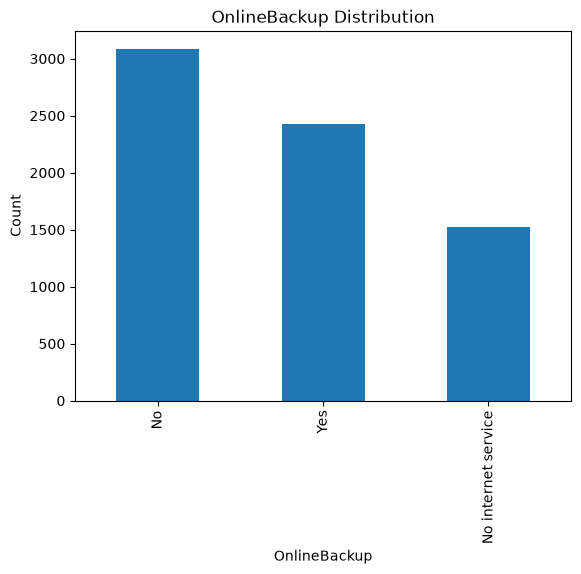

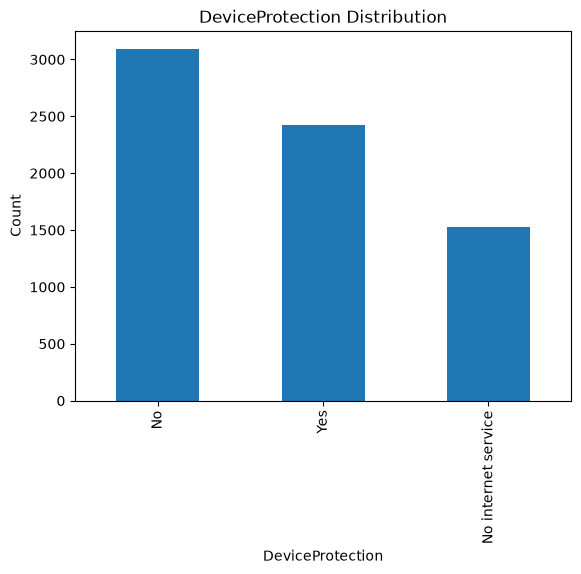

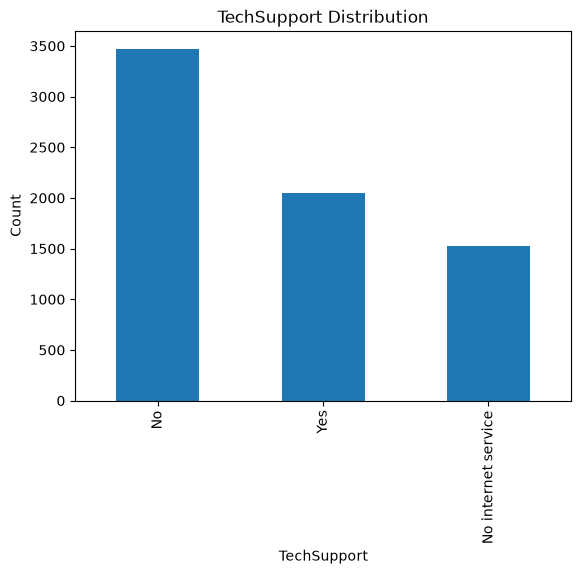

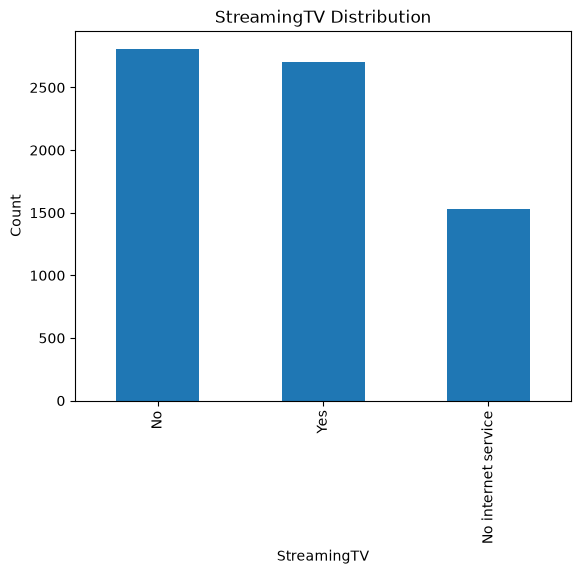

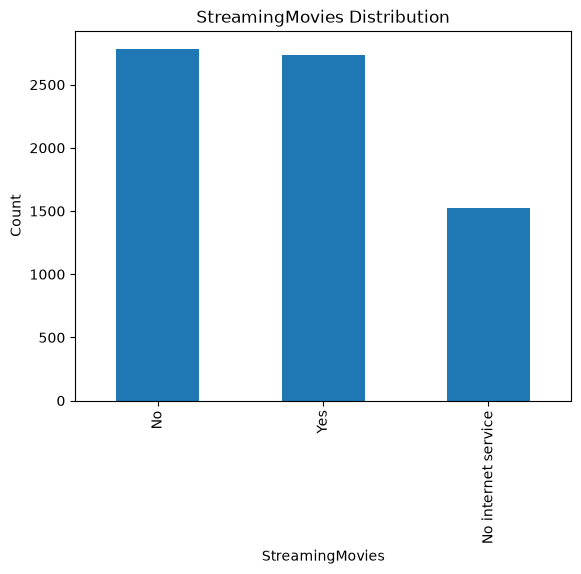

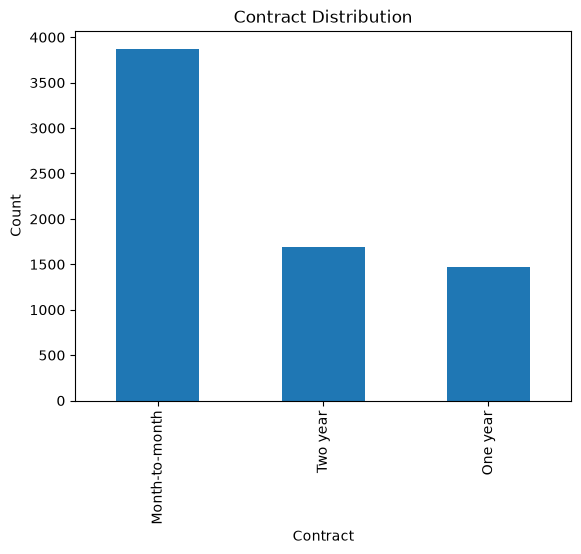

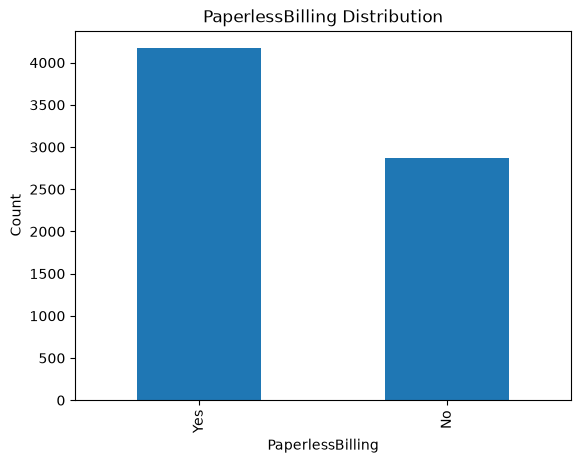

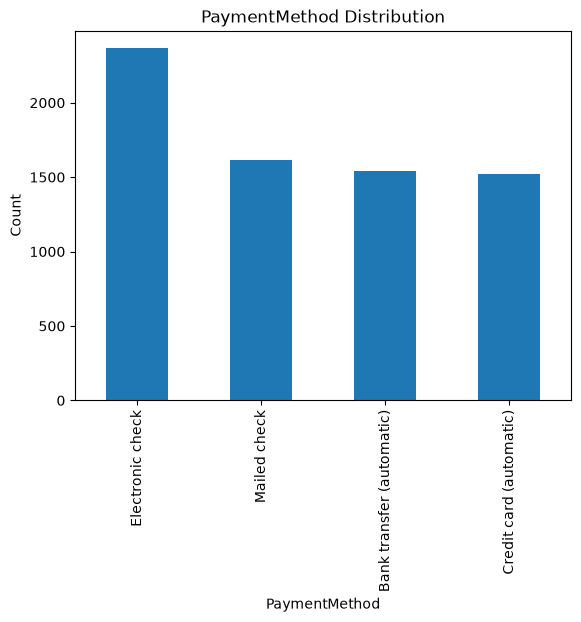

In [36]:
import matplotlib.pyplot as plt
for col in categorical_cols:
    # bar plot for categorical columns
    df[col].value_counts().plot(kind='bar', title=f'{col} Distribution',
                                xlabel=col, ylabel='Count')
    plt.show()

# Feature Engineering

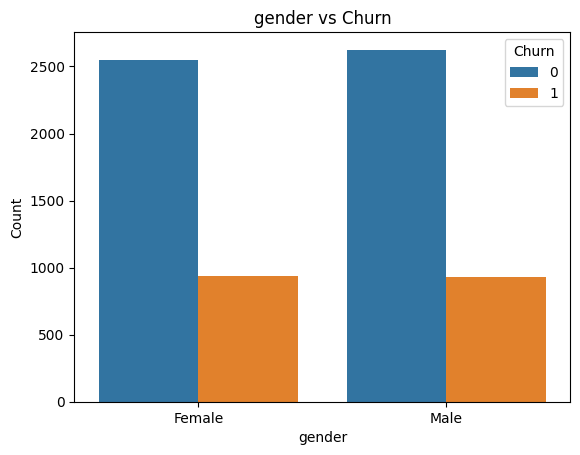

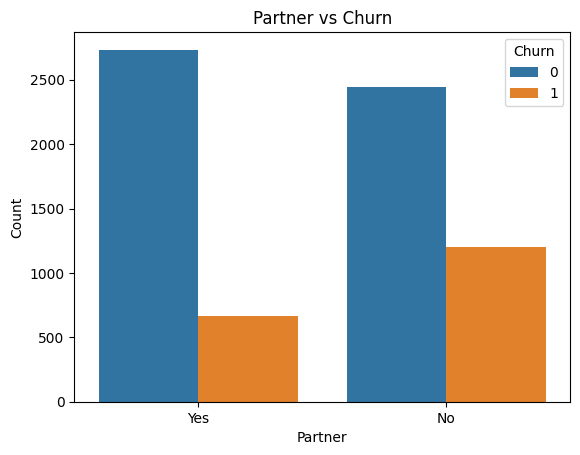

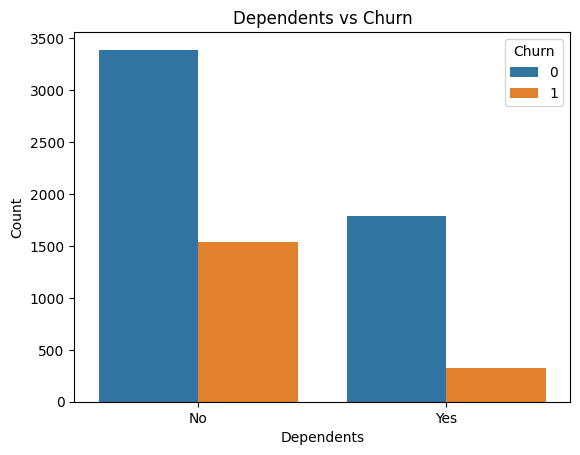

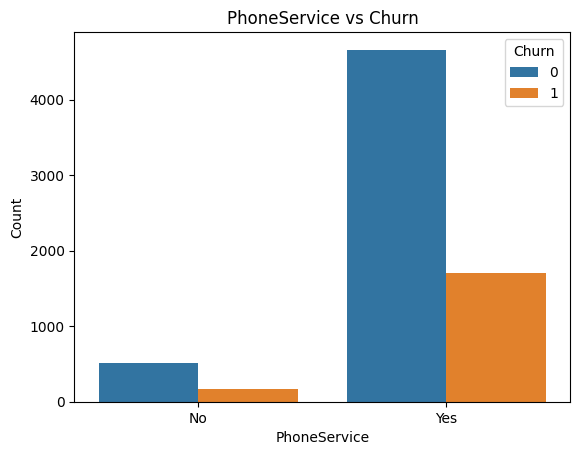

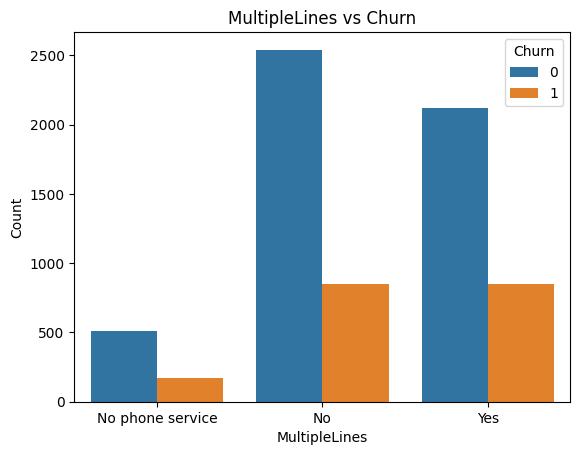

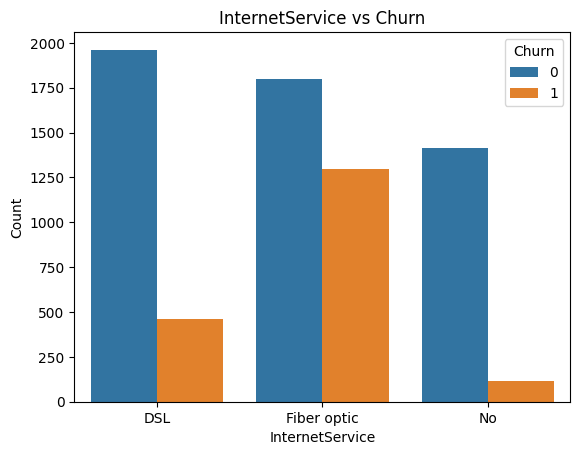

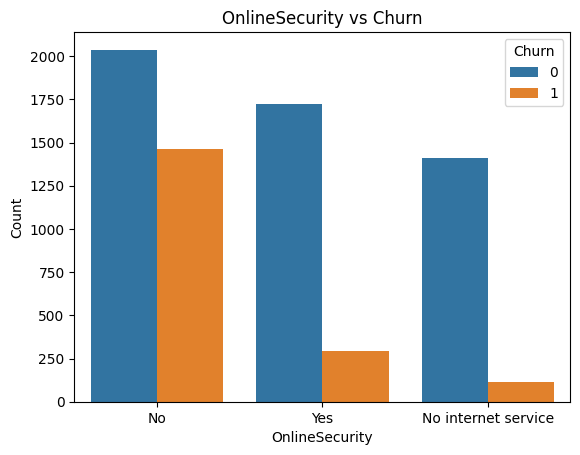

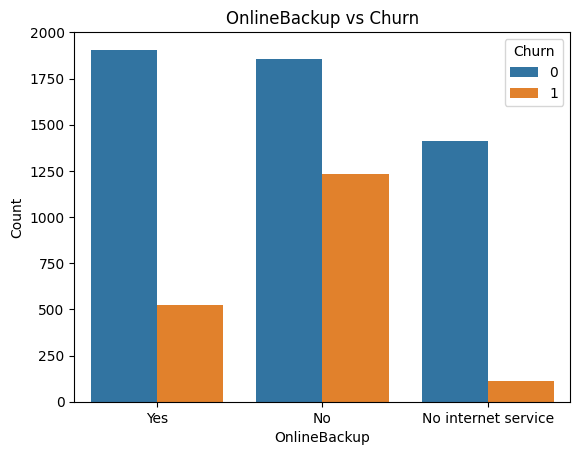

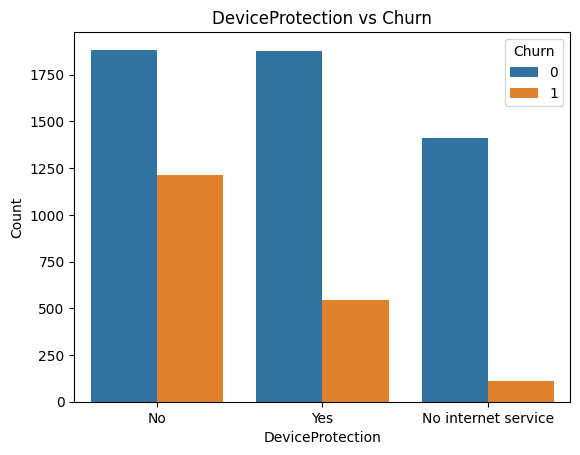

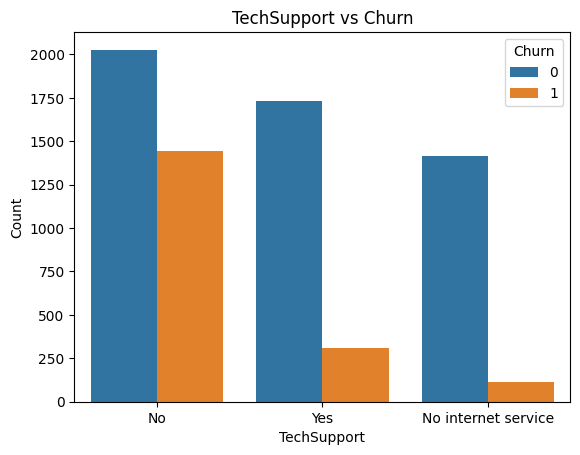

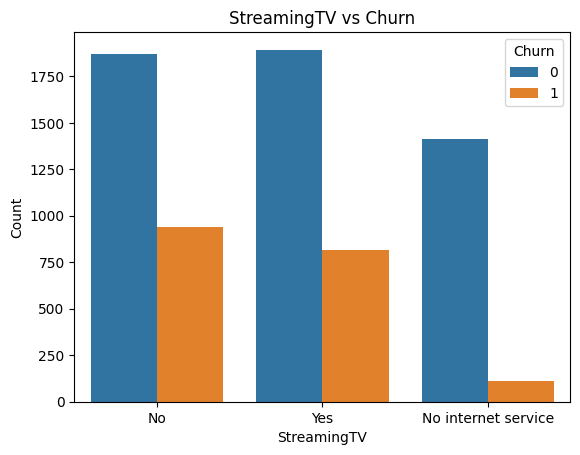

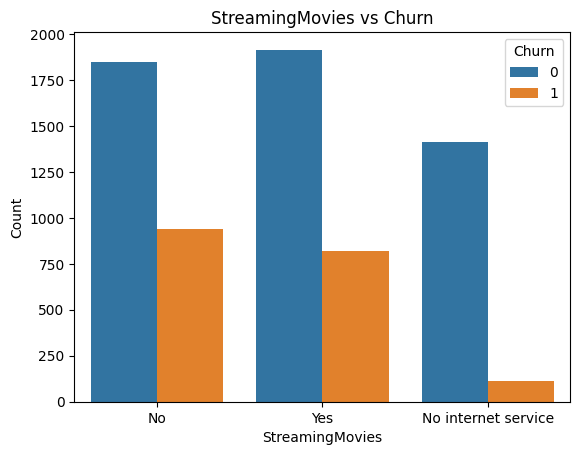

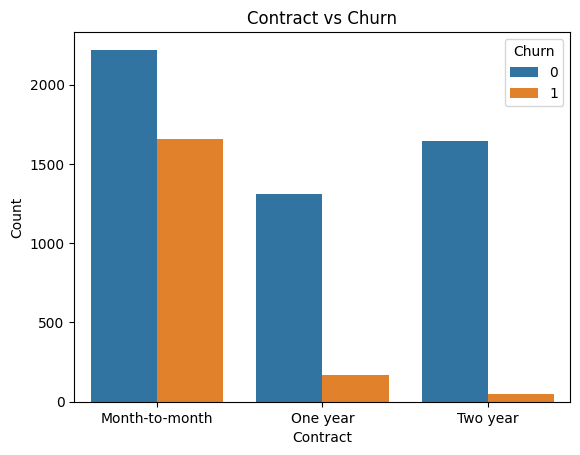

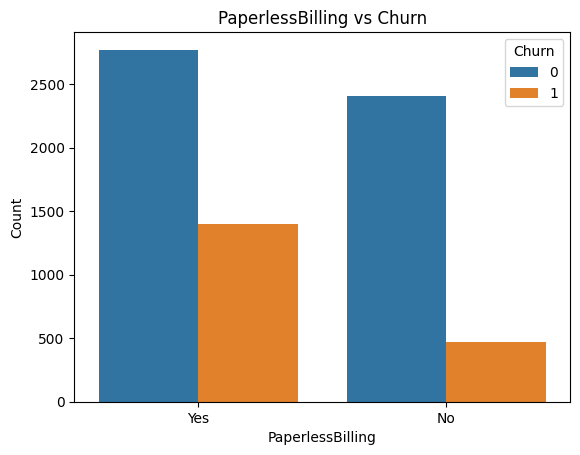

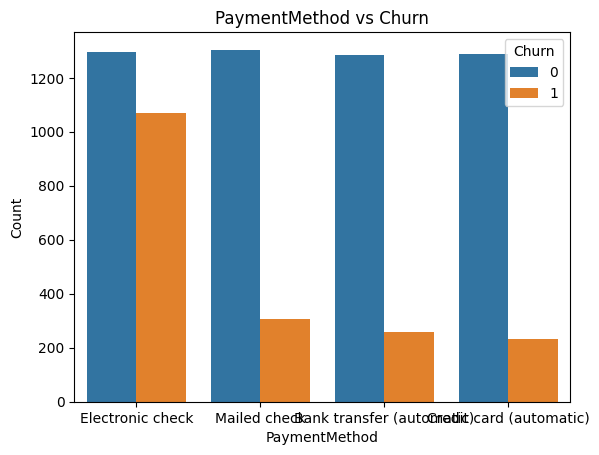

In [ ]:
for col in categorical_cols:
    sns.countplot(x=col, hue=target_col, data=df)
    plt.title(f'{col} vs {target_col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title=target_col, loc='upper right')
    plt.show()

# Pairplot for numerical columns colored by the target variable

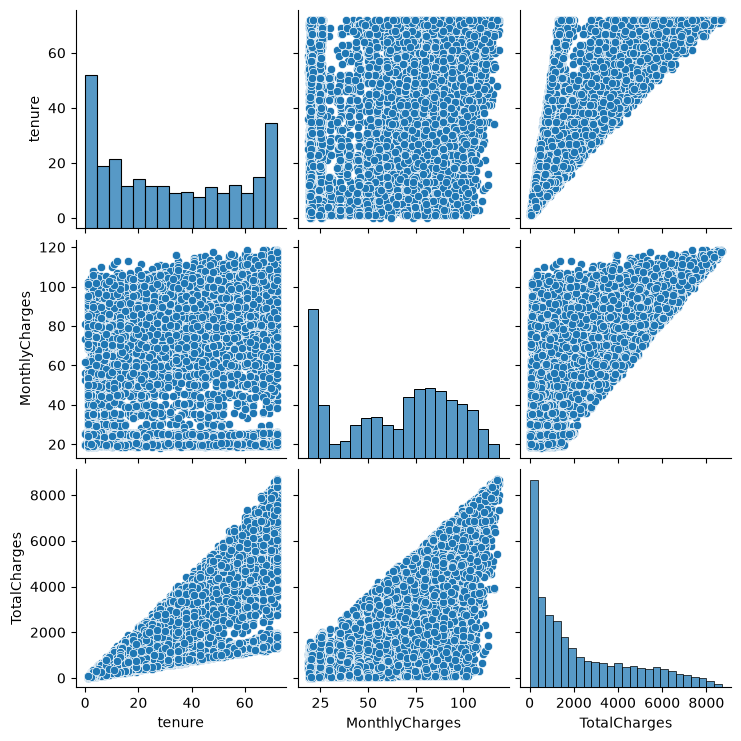

In [ ]:
sns.pairplot(df, vars=numerical_cols)

# Create dummy variables for the categorical columns, dropping the first category to avoid multicollinearity

In [38]:
df.info()
df.columns
# Create dummy variables for the categorical columns, dropping the first category to avoid multicollinearity
df1= pd.get_dummies(data=df,columns=['gender', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
        'Churn'], drop_first=True)
df1.shape


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

(7043, 31)

Now, the number of columns is 31.

# Describe the data

In [39]:
df.shape
df1.shape
df1.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_1
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


# Checking null values

In [40]:
df1.isna().sum()

SeniorCitizen                             0
tenure                                    0
MonthlyCharges                            0
TotalCharges                             11
gender_Male                               0
Partner_Yes                               0
Dependents_Yes                            0
PhoneService_Yes                          0
MultipleLines_No phone service            0
MultipleLines_Yes                         0
InternetService_Fiber optic               0
InternetService_No                        0
OnlineSecurity_No internet service        0
OnlineSecurity_Yes                        0
OnlineBackup_No internet service          0
OnlineBackup_Yes                          0
DeviceProtection_No internet service      0
DeviceProtection_Yes                      0
TechSupport_No internet service           0
TechSupport_Yes                           0
StreamingTV_No internet service           0
StreamingTV_Yes                           0
StreamingMovies_No internet serv

# There are 11 missing values in the 'TotalCharges' column. We can choose to fill these missing values with the median of the column, as it is less affected by outliers than the mean.

In [41]:
from sklearn.impute import SimpleImputer
import numpy as np
imputer = SimpleImputer(strategy='mean',missing_values=np.nan)
df1['TotalCharges'] = imputer.fit_transform(df1['TotalCharges'].values.reshape(-1, 1))
df1.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_1
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


# Scaling the features using StandardScaler

In [42]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(df1.drop(['Churn_1'], axis=1))
scaled_features = scaler.transform(df1.drop(['Churn_1'], axis=1))

# Train test split

In [43]:
from sklearn.model_selection import train_test_split
X = scaled_features
y= df1['Churn_1']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                     random_state=42)

# Random Forest Classifier

In [44]:
# Train a Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
predictions =model.predict(X_test)

# Performance Analysis

In [45]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, predictions))
confusion_matrix(y_test, predictions)

# train accuracy
rf_train_accuracy = model.score(X_train, y_train)*100
print(f'Train Accuracy: {rf_train_accuracy:.2f}%')
rf_model_accuracy = model.score(X_test, y_test)*100
print(f'Model Accuracy: {rf_model_accuracy:.2f}%')

              precision    recall  f1-score   support

       False       0.82      0.91      0.87      1539
        True       0.67      0.47      0.55       574

    accuracy                           0.79      2113
   macro avg       0.75      0.69      0.71      2113
weighted avg       0.78      0.79      0.78      2113

Train Accuracy: 99.84%
Model Accuracy: 79.37%


# Logistic Regression

              precision    recall  f1-score   support

       False       0.85      0.90      0.87      1539
        True       0.68      0.57      0.62       574

    accuracy                           0.81      2113
   macro avg       0.77      0.74      0.75      2113
weighted avg       0.80      0.81      0.81      2113

Train Accuracy: 80.51%
Model Accuracy: 81.21%


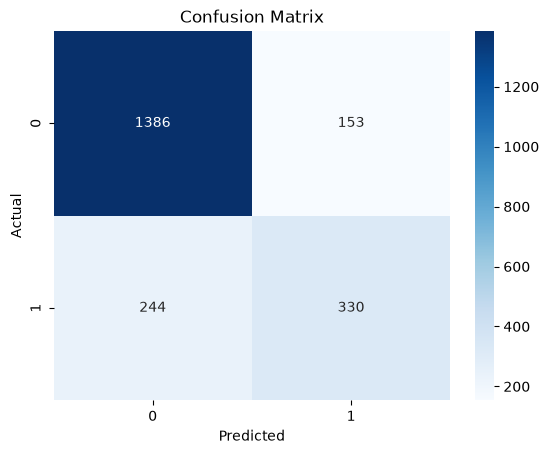

In [46]:
# logistic regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
predictions =model.predict(X_test)
print(classification_report(y_test, predictions))
classification_report(y_test, predictions)
# train accuracy
lr_train_accuracy = model.score(X_train, y_train)*100
print(f'Train Accuracy: {lr_train_accuracy:.2f}%')
lr_test_accuracy = model.score(X_test, y_test)*100
print(f'Model Accuracy: {lr_test_accuracy:.2f}%')

plt_confusion_matrix = confusion_matrix(y_test, predictions)
sns.heatmap(plt_confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted') 
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Decision Tree Classifier

              precision    recall  f1-score   support

       False       0.82      0.82      0.82      1539
        True       0.52      0.51      0.51       574

    accuracy                           0.74      2113
   macro avg       0.67      0.67      0.67      2113
weighted avg       0.74      0.74      0.74      2113

Train Accuracy: 99.84%
Model Accuracy: 73.73%


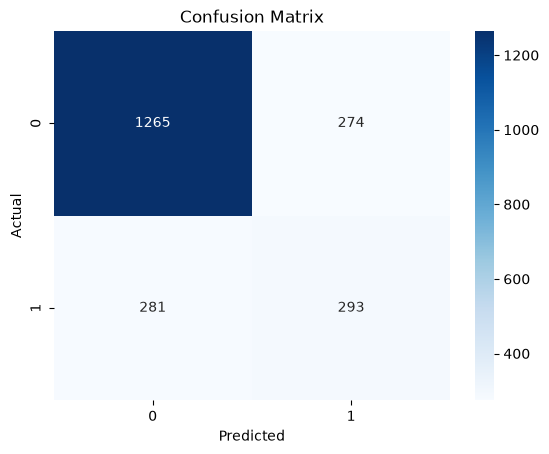

In [47]:
# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train,y_train)
predictions = model.predict(X_test)
print(classification_report(y_test, predictions))
confusion_matrix(y_test, predictions)
dt_train_accuracy = model.score(X_train, y_train)*100
print(f'Train Accuracy: {dt_train_accuracy:.2f}%')
dt_test_accuracy = model.score(X_test, y_test)*100
print(f'Model Accuracy: {dt_test_accuracy:.2f}%')
plt_confusion_matrix = confusion_matrix(y_test, predictions)
sns.heatmap(plt_confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Support Vector Classifier

              precision    recall  f1-score   support

       False       0.85      0.90      0.87      1539
        True       0.67      0.56      0.61       574

    accuracy                           0.81      2113
   macro avg       0.76      0.73      0.74      2113
weighted avg       0.80      0.81      0.80      2113

[[1382  157]
 [ 251  323]]
Train Accuracy: 79.94%
Model Accuracy: 80.69%


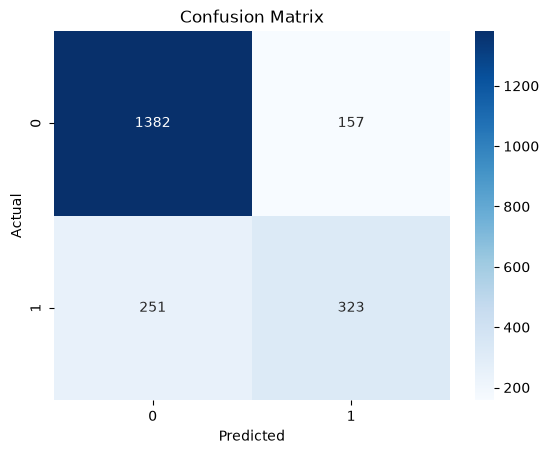

In [48]:
#Support Vector Machine
from sklearn.svm import SVC
model = SVC(kernel='linear', random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
print(classification_report(y_test, predictions))
print(confusion_matrix(y_test, predictions))
svc_train_accuracy = model.score(X_train, y_train)*100
print(f'Train Accuracy: {svc_train_accuracy:.2f}%')
svc_test_accuracy = model.score(X_test, y_test)*100
print(f'Model Accuracy: {svc_test_accuracy:.2f}%')
plt_confusion_matrix = confusion_matrix(y_test, predictions)
sns.heatmap(plt_confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted') 
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()